<a href="https://colab.research.google.com/github/Yash-Yelave/AEAI/blob/main/Grad_CAM_CNN_AEAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple CNN_Grad_CAM

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.9536 - loss: 0.1549
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.9862 - loss: 0.0458
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9905 - loss: 0.0310


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_2']]
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


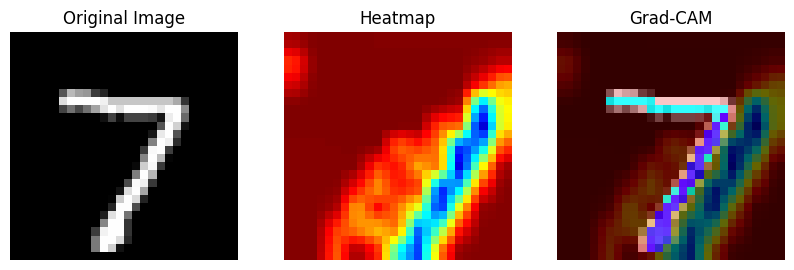

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

inputs = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(16, (3,3), activation='relu', name='conv1')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', name='conv2')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, batch_size=64, verbose=1)

def get_gradcam_heatmap(model, image, last_conv_layer_name):
  grad_model = tf.keras.models.Model(
      inputs = [model.inputs],
      outputs = [model.get_layer(last_conv_layer_name).output, model.output]
  )
  with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(image, training=False)
    class_idx = tf.argmax(predictions[0])
    loss = predictions[:, class_idx]

  grads = tape.gradient(loss, conv_outputs)

  pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
  conv_outputs = conv_outputs[0]

  heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
  return heatmap.numpy()

img = x_test[0]
img_input = np.expand_dims(img, axis=0)

heatmap = get_gradcam_heatmap(model, img_input, 'conv2')

heatmap = cv2.resize(heatmap, (28,28))
heatmap = np.uint8(heatmap * 255)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

img_rgb = np.repeat(img, 3, axis=-1)
img_rgb = np.uint8(img_rgb * 255)

superimposed_img = heatmap * 0.4 + img_rgb

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(superimposed_img.astype('uint8'))
plt.axis('off')

plt.show()